# HPC Asia 2026 - Poster Presentation - Plots

In [1]:
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Iterable, Tuple

from seaborn import color_palette

import plot_benchmark
from pathlib import Path
import os

%load_ext autoreload
%autoreload
%matplotlib inline



First, we merge the data and accumulate it into a single dataframe for analysis.

In [2]:
results_time = {
    "RTX2080" : Path("../results/rtx2080/RTX2080_Benchmark_Result.csv"),
    "RTX3080" : Path("../results/rtx3080/RTX3080_Benchmark_Result.csv"),
    "RTX4060" : Path("../results/rtx4060/RTX4060_Benchmark_Result.csv"),
    "RTX5080" : Path("../results/rtx5080/RTX5080_Benchmark_Result.csv"),
}
dfs = []
for gpu, path in results_time.items():
    dfs.append(pd.read_csv(path))
    dfs[-1]["GPU"] = gpu
# Merge all dfs into a single pd.Dataframe:
df_runtime = pd.concat(dfs)
df_runtime

,Name,Framework,Precision,Problem Size,Iterations,Wall Clock Time,CPU Time,Kernel Time,Position Update Time,Velocity Update Time,Force Update Time,Time Unit,Version,Framework[Version],GPU
0,MatrixMultiplication,Alpaka,float,32,8176.0,7.831260e+04,7.812443e+04,2.394853e+04,NaN,NaN,NaN,ns,NaN,Alpaka,RTX2080
1,MatrixMultiplication,Alpaka,float,64,6900.0,1.129272e+05,1.126394e+05,3.995484e+04,NaN,NaN,NaN,ns,NaN,Alpaka,RTX2080
2,MatrixMultiplication,Alpaka,float,128,4426.0,1.576464e+05,1.573337e+05,7.470166e+04,NaN,NaN,NaN,ns,NaN,Alpaka,RTX2080
3,MatrixMultiplication,Alpaka,float,256,1168.0,6.227995e+05,6.217590e+05,4.624265e+05,NaN,NaN,NaN,ns,NaN,Alpaka,RTX2080
4,MatrixMultiplication,Alpaka,float,512,176.0,3.889060e+06,3.883924e+06,3.329796e+06,NaN,NaN,NaN,ns,NaN,Alpaka,RTX2080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,PolyhedralGravity,Vulkan,float,255932,1000.0,7.884460e+06,7.099255e+04,NaN,NaN,NaN,NaN,ns,NaN,Vulkan,RTX5080
240,PolyhedralGravity,OpenACC,float,14744,2439.0,2.875179e+05,2.874951e+05,NaN,NaN,NaN,NaN,ns,NaN,OpenACC,RTX5080
241,PolyhedralGravity,OpenACC,float,255932,243.0,2.881376e+06,2.880761e+06,NaN,NaN,NaN,NaN,ns,NaN,OpenACC,RTX5080
242,PolyhedralGravity,OpenCL,float,14744,6953.0,9.924546e+04,9.922349e+04,NaN,NaN,NaN,NaN,ns,NaN,OpenCL,RTX5080


In [126]:
results_code_complexity = Path("../results/code-complexity/code-complexity.csv")
df_complexity = pd.read_csv(results_code_complexity)
df_complexity["n"] = df_complexity["n1"] + df_complexity["n2"]
df_complexity["N"] = df_complexity["N1"] + df_complexity["N2"]
df_complexity["V"] = df_complexity["N"] * np.log2(df_complexity["n"].replace(0, np.nan))
df_complexity["D"] = (df_complexity["n1"] / 2) * (df_complexity["N2"] / df_complexity["n2"].replace(0, np.nan))
df_complexity["E"] = df_complexity["D"] * df_complexity["V"]
df_complexity.rename(columns={"Framework": "Framework[Version]"}, inplace=True)
df_complexity

,Name,Framework[Version],SLOC,n1,n2,N1,N2,n,N,V,D,E
0,VecAdd,CPP,30,37,42,183,89,79,272,1714.628364,39.202381,6.721751e+04
1,VecAdd,Alpaka,83,44,96,487,295,140,782,5575.099319,67.604167,3.768999e+05
2,VecAdd,Boost,49,51,57,322,187,108,509,3438.237739,83.657895,2.876357e+05
3,VecAdd,AdaptiveCpp,47,52,64,338,154,116,492,3374.126650,62.562500,2.110938e+05
4,VecAdd,Cuda,76,61,48,399,172,109,571,3864.633249,109.291667,4.223722e+05
5,VecAdd,Cublas,66,48,47,368,159,95,527,3462.313906,81.191489,2.811104e+05
6,VecAdd,OpenACC,41,52,52,246,123,104,369,2472.462256,61.500000,1.520564e+05
7,VecAdd,OpenCL,143,82,96,894,369,178,1263,9441.851323,157.593750,1.487977e+06
8,VecAdd,OpenMP,37,45,53,219,121,98,340,2249.001347,51.367925,1.155265e+05
9,VecAdd,Vulkan,206,92,198,1394,769,290,2163,17693.143362,178.656566,3.160996e+06


In [127]:
# Merge df_results and df_complexity on ['Name', 'Framework']
df = pd.merge(df_runtime, df_complexity, on=["Name", "Framework[Version]"], how="inner")
#df = pd.merge(df_runtime, df_complexity, on=["Name", "Framework"], how="inner")
df = df.drop(columns=["Precision", "Iterations", "Time Unit"])
df

,Name,Framework,Problem Size,Wall Clock Time,CPU Time,Kernel Time,Position Update Time,Velocity Update Time,Force Update Time,Version,...,SLOC,n1,n2,N1,N2,n,N,V,D,E
0,MatrixMultiplication,Alpaka,32,7.831260e+04,7.812443e+04,2.394853e+04,NaN,NaN,NaN,NaN,...,109,48,116,635,405,164,1040,7651.854085,83.793103,6.411726e+05
1,MatrixMultiplication,Alpaka,64,1.129272e+05,1.126394e+05,3.995484e+04,NaN,NaN,NaN,NaN,...,109,48,116,635,405,164,1040,7651.854085,83.793103,6.411726e+05
2,MatrixMultiplication,Alpaka,128,1.576464e+05,1.573337e+05,7.470166e+04,NaN,NaN,NaN,NaN,...,109,48,116,635,405,164,1040,7651.854085,83.793103,6.411726e+05
3,MatrixMultiplication,Alpaka,256,6.227995e+05,6.217590e+05,4.624265e+05,NaN,NaN,NaN,NaN,...,109,48,116,635,405,164,1040,7651.854085,83.793103,6.411726e+05
4,MatrixMultiplication,Alpaka,512,3.889060e+06,3.883924e+06,3.329796e+06,NaN,NaN,NaN,NaN,...,109,48,116,635,405,164,1040,7651.854085,83.793103,6.411726e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879,PolyhedralGravity,Vulkan,255932,7.884460e+06,7.099255e+04,NaN,NaN,NaN,NaN,NaN,...,1074,185,520,6021,3749,705,9770,92438.654200,666.889423,6.164636e+07
880,PolyhedralGravity,OpenACC,14744,2.875179e+05,2.874951e+05,NaN,NaN,NaN,NaN,NaN,...,570,86,252,3452,2022,338,5474,45986.414034,345.023810,1.586641e+07
881,PolyhedralGravity,OpenACC,255932,2.881376e+06,2.880761e+06,NaN,NaN,NaN,NaN,NaN,...,570,86,252,3452,2022,338,5474,45986.414034,345.023810,1.586641e+07
882,PolyhedralGravity,OpenCL,14744,9.924546e+04,9.922349e+04,NaN,NaN,NaN,NaN,NaN,...,764,96,352,4319,2748,448,7067,62241.577234,374.727273,2.332362e+07


In [129]:
export_results = Path("../results/all_results.csv")
if not export_results.exists():
    df.to_csv(export_results, index=False)
    print("Results exported!")
else:
    print("Results already exported!")

Results exported!


Plotting of the results

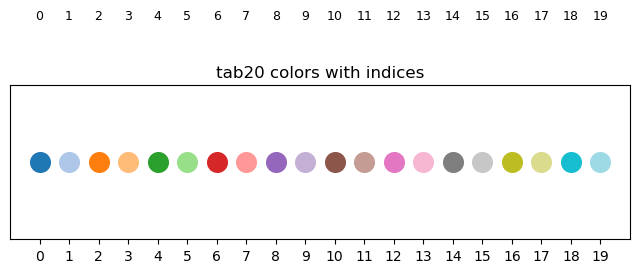

In [130]:
colors = matplotlib.colormaps["tab20"].colors
plt.figure(figsize=(8, 2))
for i, c in enumerate(colors):
    plt.scatter(i, 0, color=c, s=200)
    plt.text(i, 0.1, str(i), ha="center", va="bottom", fontsize=9)
plt.yticks([])
plt.xticks(range(len(colors)))
plt.xlim(-1, len(colors))
plt.title("tab20 colors with indices")
plt.grid(False)
plt.show()

In [136]:
df["Framework[Version]"].unique()

array(['Alpaka', 'OpenMP', 'Vulkan', 'AdaptiveCpp[Naive]',
       'AdaptiveCpp[SharedMemory]', 'CPP', 'OpenCL', 'Boost', 'Kokkos',
       'Cublas', 'Cuda[Naive]', 'Cuda[SharedMemory]', 'AdaptiveCpp',
       'Cuda', 'OpenACC', 'Slang-Cuda', 'Slang-Vulkan'], dtype=object)

In [137]:
frameworks = [
    "Alpaka", "OpenMP", "Vulkan", "AdaptiveCpp[Naive]", "AdaptiveCpp-Shr",
    "CPP", "OpenCL", "Boost", "Kokkos", "Cublas", "Cuda", "Cuda-Shr",
    "OpenACC", "Slang-Cuda", "Slang-Vulkan"
]
tab20 = matplotlib.colormaps["tab20"].colors
color_map = {
    "CPP": tab20[0],

    "Vulkan": tab20[2],
    "Slang-Vulkan": tab20[3],

    "Cuda": tab20[8],
    "Cuda[Naive]": tab20[8],
    "Slang-Cuda": tab20[9],
    "Cuda-Shr": tab20[12],
    "Cuda[SharedMemory]": tab20[12],
    "Cublas": tab20[13],

    "AdaptiveCpp[Naive]": tab20[4],
    "AdaptiveCpp": tab20[4],
    "AdaptiveCpp[SharedMemory]": tab20[5],

    "OpenACC": tab20[14],
    "OpenMP": tab20[18],

    "Alpaka": tab20[10],

    "OpenCL": tab20[16],
    "Boost": tab20[17],

    "Kokkos": tab20[6],
}

In [169]:
# USE_FRAMEWORK = "Framework"
USE_FRAMEWORK = "Framework[Version]"


def filter_and_normalize(df: pd.DataFrame,
                         name: str,
                         problem_size: int,
                         runtime: str = "Kernel Time",
                         exclude: str | list[str] = "Cublas") -> pd.DataFrame:
    """
    Filter by Name and Problem Size, exclude frameworks, and compute:
    - Application Efficiency [%]: normalized inverse of chosen runtime column (lower is better -> higher score)
      computed separately within each GPU group.
    """
    df = df.copy()
    required_cols = {USE_FRAMEWORK, "Name", "Problem Size", runtime, "GPU", "E", "SLOC"}
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Filter by name and problem size
    out = df.loc[(df["Name"] == name) & (df["Problem Size"] == problem_size)].copy()

    # Exclude frameworks
    if exclude:
        excl = [exclude] if isinstance(exclude, str) else list(exclude)
        out = out.loc[~out[USE_FRAMEWORK].isin(excl)]

    # Drop columns not needed for the analysis if they exist
    to_drop = ["Name", "Problem Size"]
    existing_drop = [c for c in to_drop if c in out.columns]
    if existing_drop:
        out.drop(columns=existing_drop, inplace=True)

    # Application Efficiency per GPU: normalize inverse within each GPU group (best/fastest in GPU = 100)
    runtime_series = out[runtime].astype(float)
    min_per_gpu = runtime_series.groupby(out["GPU"]).transform("min")
    out["Application Efficiency [%]"] = (min_per_gpu / runtime_series) * 100.0

    # Calculate performance portability from the Application Efficiency (harmonic mean across GPUs)
    ae_per_fw_gpu = (
        out.groupby([USE_FRAMEWORK, "GPU"], as_index=False)["Application Efficiency [%]"]
        .mean()
        .rename(columns={"Application Efficiency [%]": "_AE"})
    )
    ae_per_fw_gpu["_inv_AE"] = np.where(ae_per_fw_gpu["_AE"] > 0.0, 1.0 / ae_per_fw_gpu["_AE"], np.nan)

    n_platforms_per_fw = ae_per_fw_gpu.groupby(USE_FRAMEWORK)["GPU"].nunique()
    inv_ae_sum_per_fw = ae_per_fw_gpu.groupby(USE_FRAMEWORK)["_inv_AE"].sum(min_count=1)

    pp_per_fw = (n_platforms_per_fw / inv_ae_sum_per_fw).replace([np.inf, -np.inf], np.nan)
    out["Performance Portability [%]"] = out[USE_FRAMEWORK].map(pp_per_fw)

    # Halstead Effort normalized to max=100
    e_series = out["E"].astype(float)
    sloc_series = out["SLOC"].astype(int)
    # get the halstead effort for the C++ implementation; df["Framework"] = "CPP
    # this not actually the min, but the values are the same independent of the GPU being used
    cpp_e = out[out[USE_FRAMEWORK] == "CPP"]["E"].astype(float).min()
    cpp_sloc = out[out[USE_FRAMEWORK] == "CPP"]["SLOC"].astype(float).min()
    max_e = e_series.max()
    out["Halstead Effort [%]"] = (e_series / cpp_e) * 100.0 if np.isfinite(
        max_e) and max_e != 0 else e_series
    out["SLOC Difference [1]"] = sloc_series - cpp_sloc
    out["SLOC Difference [%]"] = sloc_series / cpp_sloc * 100.0

    return out


def filter_and_concat(
        df: pd.DataFrame,
        queries: Iterable[Tuple[str, int, str | None]],
        exclude: str | list[str] = "Cublas",
) -> pd.DataFrame:
    """
    Run filter_and_normalize multiple times and concatenate results.
    Each query is a tuple of (name, problem_size, runtime). If runtime is None, defaults to "Kernel Time".
    The resulting dataframe will include the original Name and Problem Size for each query.
    """
    frames: list[pd.DataFrame] = []
    for q in queries:
        if len(q) != 3:
            raise ValueError("Each query must be a tuple: (name, problem_size, runtime)")
        name, problem_size, runtime = q
        rt = runtime if runtime is not None else "Kernel Time"
        out = filter_and_normalize(df, name=name, problem_size=problem_size, runtime=rt, exclude=exclude).copy()
        # Re-add the identifying columns
        out["Name"] = name
        out["Problem Size"] = problem_size
        out["Runtime Column"] = rt
        frames.append(out)

    if not frames:
        return pd.DataFrame(columns=["Name", "Problem Size", "Runtime Column"])

    return pd.concat(frames, ignore_index=True)


In [170]:
df_polyhedral = filter_and_concat(df, [("PolyhedralGravity", 14744, "Wall Clock Time"), ("PolyhedralGravity", 255932, "Wall Clock Time")])

/var/folders/d7/j4pv5c3d1nj5jmjlz_bpj2lh0000gn/T/ipykernel_50564/1045607328.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0.0, 0.0, 0.86, 1.0))


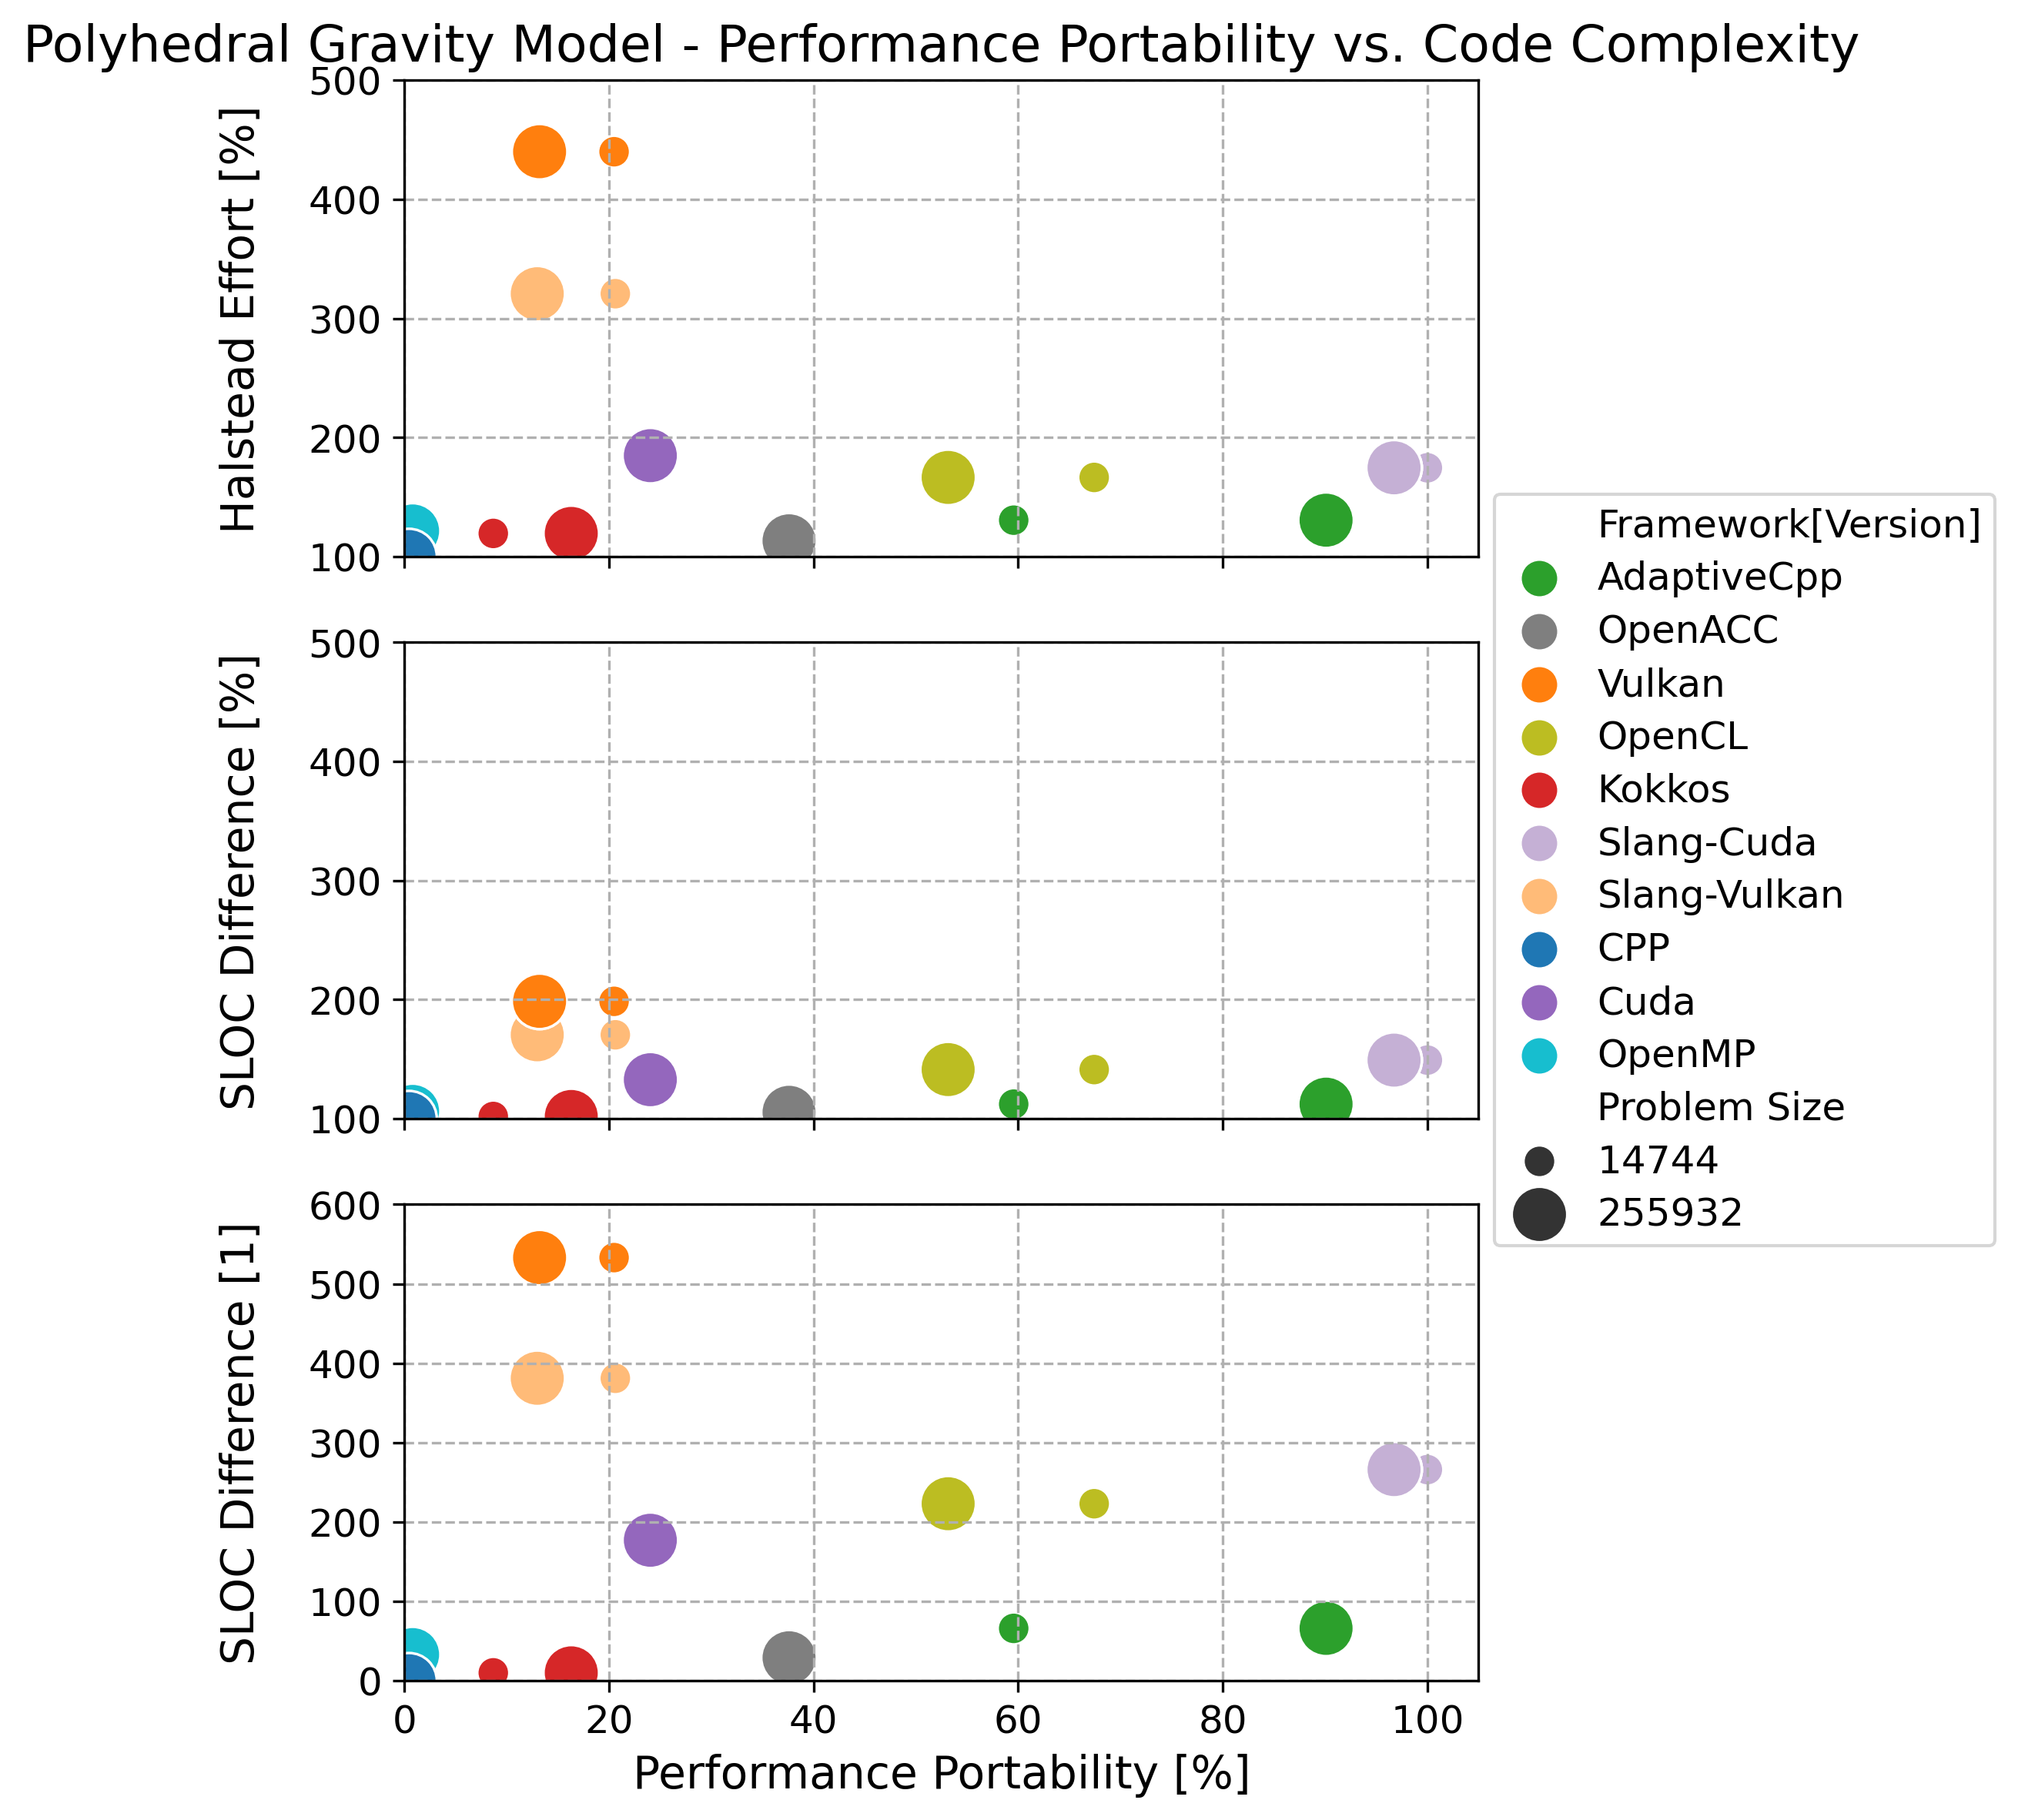

In [171]:
local_df = df_polyhedral
topic = "Polyhedral Gravity Model"
x_axis = "Performance Portability [%]"
y1_axis = "Halstead Effort [%]"
y1_axis_lim = (100, 500)
y2_axis = "SLOC Difference [%]"
y2_axis_lim = (100, 500)
y3_axis = "SLOC Difference [1]"
y3_axis_lim = (0, 600)
sizes = [100, 300]

fig, (ax_top, ax_mid, ax_bot) = plt.subplots(
    3, 1,
    sharex=True,
    figsize=(6, 9),
    gridspec_kw={"height_ratios": [1, 1, 1], "hspace": 0.18}
)

ax_top = sns.scatterplot(
    data=local_df,
    x=x_axis,
    y=y1_axis,
    hue=USE_FRAMEWORK,
    size="Problem Size",
    sizes=sizes,
    palette=color_map,
    s=140,
    ax=ax_top
)
ax_top.grid(True, linestyle="--")
ax_top.set_ylim(y1_axis_lim[0], y1_axis_lim[1])
ax_top.set_xlim(0, 105)
ax_top.set_title(f"{topic} - Performance Portability vs. Code Complexity", fontsize=16)
ax_top.set_xlabel("")
ax_top.set_ylabel(y1_axis, fontsize=14, labelpad=14)
ax_top.tick_params(axis="both", labelsize=12)
ax_top.tick_params(axis="x", labelbottom=False)

ax_mid = sns.scatterplot(
    data=local_df,
    x=x_axis,
    y=y2_axis,
    hue=USE_FRAMEWORK,
    size="Problem Size",
    sizes=sizes,
    palette=color_map,
    s=140,
    legend=False,
    ax=ax_mid
)
ax_mid.grid(True, linestyle="--")
ax_mid.set_ylim(y2_axis_lim[0], y2_axis_lim[1])
ax_mid.set_xlim(0, 105)
ax_mid.set_xlabel("")
ax_mid.set_ylabel(y2_axis, fontsize=14, labelpad=14)
ax_mid.tick_params(axis="both", labelsize=12)
ax_mid.tick_params(axis="x", labelbottom=False)

ax_bot = sns.scatterplot(
    data=local_df,
    x=x_axis,
    y=y3_axis,
    hue=USE_FRAMEWORK,
    size="Problem Size",
    sizes=sizes,
    palette=color_map,
    s=140,
    legend=False,
    ax=ax_bot
)
ax_bot.grid(True, linestyle="--")
ax_bot.set_ylim(y3_axis_lim[0], y3_axis_lim[1])
ax_bot.set_xlim(0, 105)
ax_bot.set_xlabel(x_axis, fontsize=14)
ax_bot.set_ylabel(y3_axis, fontsize=14, labelpad=14)
ax_bot.tick_params(axis="both", labelsize=12)

# Move shared legend to the right outside the plot
legend = ax_top.legend_
if legend is not None:
    handles, labels = legend.legend_handles, [t.get_text() for t in legend.texts]
    legend.remove()
    leg = fig.legend(
        handles, labels,
        loc="center left",
        bbox_to_anchor=(0.9, 0.5),
        frameon=True
    )
    if leg is not None:
        for txt in leg.get_texts():
            txt.set_fontsize(12)
        if leg.get_title() is not None:
            leg.get_title().set_fontsize(13)

fig.tight_layout(rect=(0.0, 0.0, 0.86, 1.0))
plt.gcf().set_dpi(300)
plt.show()


In [172]:
df_nbody = filter_and_concat(df, [
    ("NBody", 100, "Wall Clock Time"),
    ("NBody", 1000, "Wall Clock Time"),
    ("NBody", 10000, "Wall Clock Time")
])
df_nbody

,Framework,Wall Clock Time,CPU Time,Kernel Time,Position Update Time,Velocity Update Time,Force Update Time,Version,Framework[Version],GPU,...,D,E,Application Efficiency [%],Performance Portability [%],Halstead Effort [%],SLOC Difference [1],SLOC Difference [%],Name,Problem Size,Runtime Column
0,Alpaka,3.221761e+07,3.221520e+07,NaN,4.340125e+06,4.209694e+06,2.117024e+07,NaN,Alpaka,RTX2080,...,162.484756,3.192320e+06,43.408704,45.669611,436.079566,139.0,229.906542,NBody,100,Wall Clock Time
1,OpenMP,2.909839e+08,2.703096e+07,NaN,4.031329e+07,1.704602e+07,2.335244e+08,NaN,OpenMP,RTX2080,...,203.233333,3.058358e+06,4.806193,4.891288,417.780090,97.0,190.654206,NBody,100,Wall Clock Time
2,Vulkan,1.485006e+09,1.395272e+09,NaN,3.116135e+08,3.235974e+08,3.296756e+08,NaN,Vulkan,RTX2080,...,245.941406,7.665929e+06,0.941764,0.745137,1047.186801,258.0,341.121495,NBody,100,Wall Clock Time
3,AdaptiveCpp,5.028758e+07,3.291510e+07,NaN,3.388450e+06,2.929583e+06,1.643356e+07,NaN,AdaptiveCpp,RTX2080,...,185.902878,2.977591e+06,27.810538,22.513258,406.746984,94.0,187.850467,NBody,100,Wall Clock Time
4,CPP,1.485699e+07,1.485682e+07,NaN,2.172130e+05,8.123936e+04,1.452457e+07,NaN,CPP,RTX2080,...,96.990000,7.320498e+05,94.132431,84.381374,100.000000,0.0,100.000000,NBody,100,Wall Clock Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,Vulkan,2.896616e+09,1.675916e+09,NaN,4.286849e+08,4.233644e+08,1.573877e+09,NaN,Vulkan,RTX5080,...,245.941406,7.665929e+06,41.509855,28.121934,1047.186801,258.0,341.121495,NBody,10000,Wall Clock Time
104,Boost,1.266736e+09,1.266540e+09,NaN,2.618528e+06,2.671680e+06,1.232895e+09,NaN,Boost,RTX5080,...,179.375000,3.206012e+06,94.919671,76.732035,437.949950,136.0,227.102804,NBody,10000,Wall Clock Time
105,Alpaka,7.751177e+09,7.749993e+09,NaN,7.891748e+06,7.040903e+06,7.732930e+09,NaN,Alpaka,RTX5080,...,162.484756,3.192320e+06,15.512241,15.514882,436.079566,139.0,229.906542,NBody,10000,Wall Clock Time
106,Kokkos,5.151393e+09,5.150571e+09,NaN,1.514837e+06,1.615498e+07,5.133009e+09,NaN,Kokkos,RTX5080,...,188.059701,2.876587e+06,23.340892,10.757808,392.949598,106.0,199.065421,NBody,10000,Wall Clock Time


/var/folders/d7/j4pv5c3d1nj5jmjlz_bpj2lh0000gn/T/ipykernel_50564/1420006170.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0.0, 0.0, 0.86, 1.0))


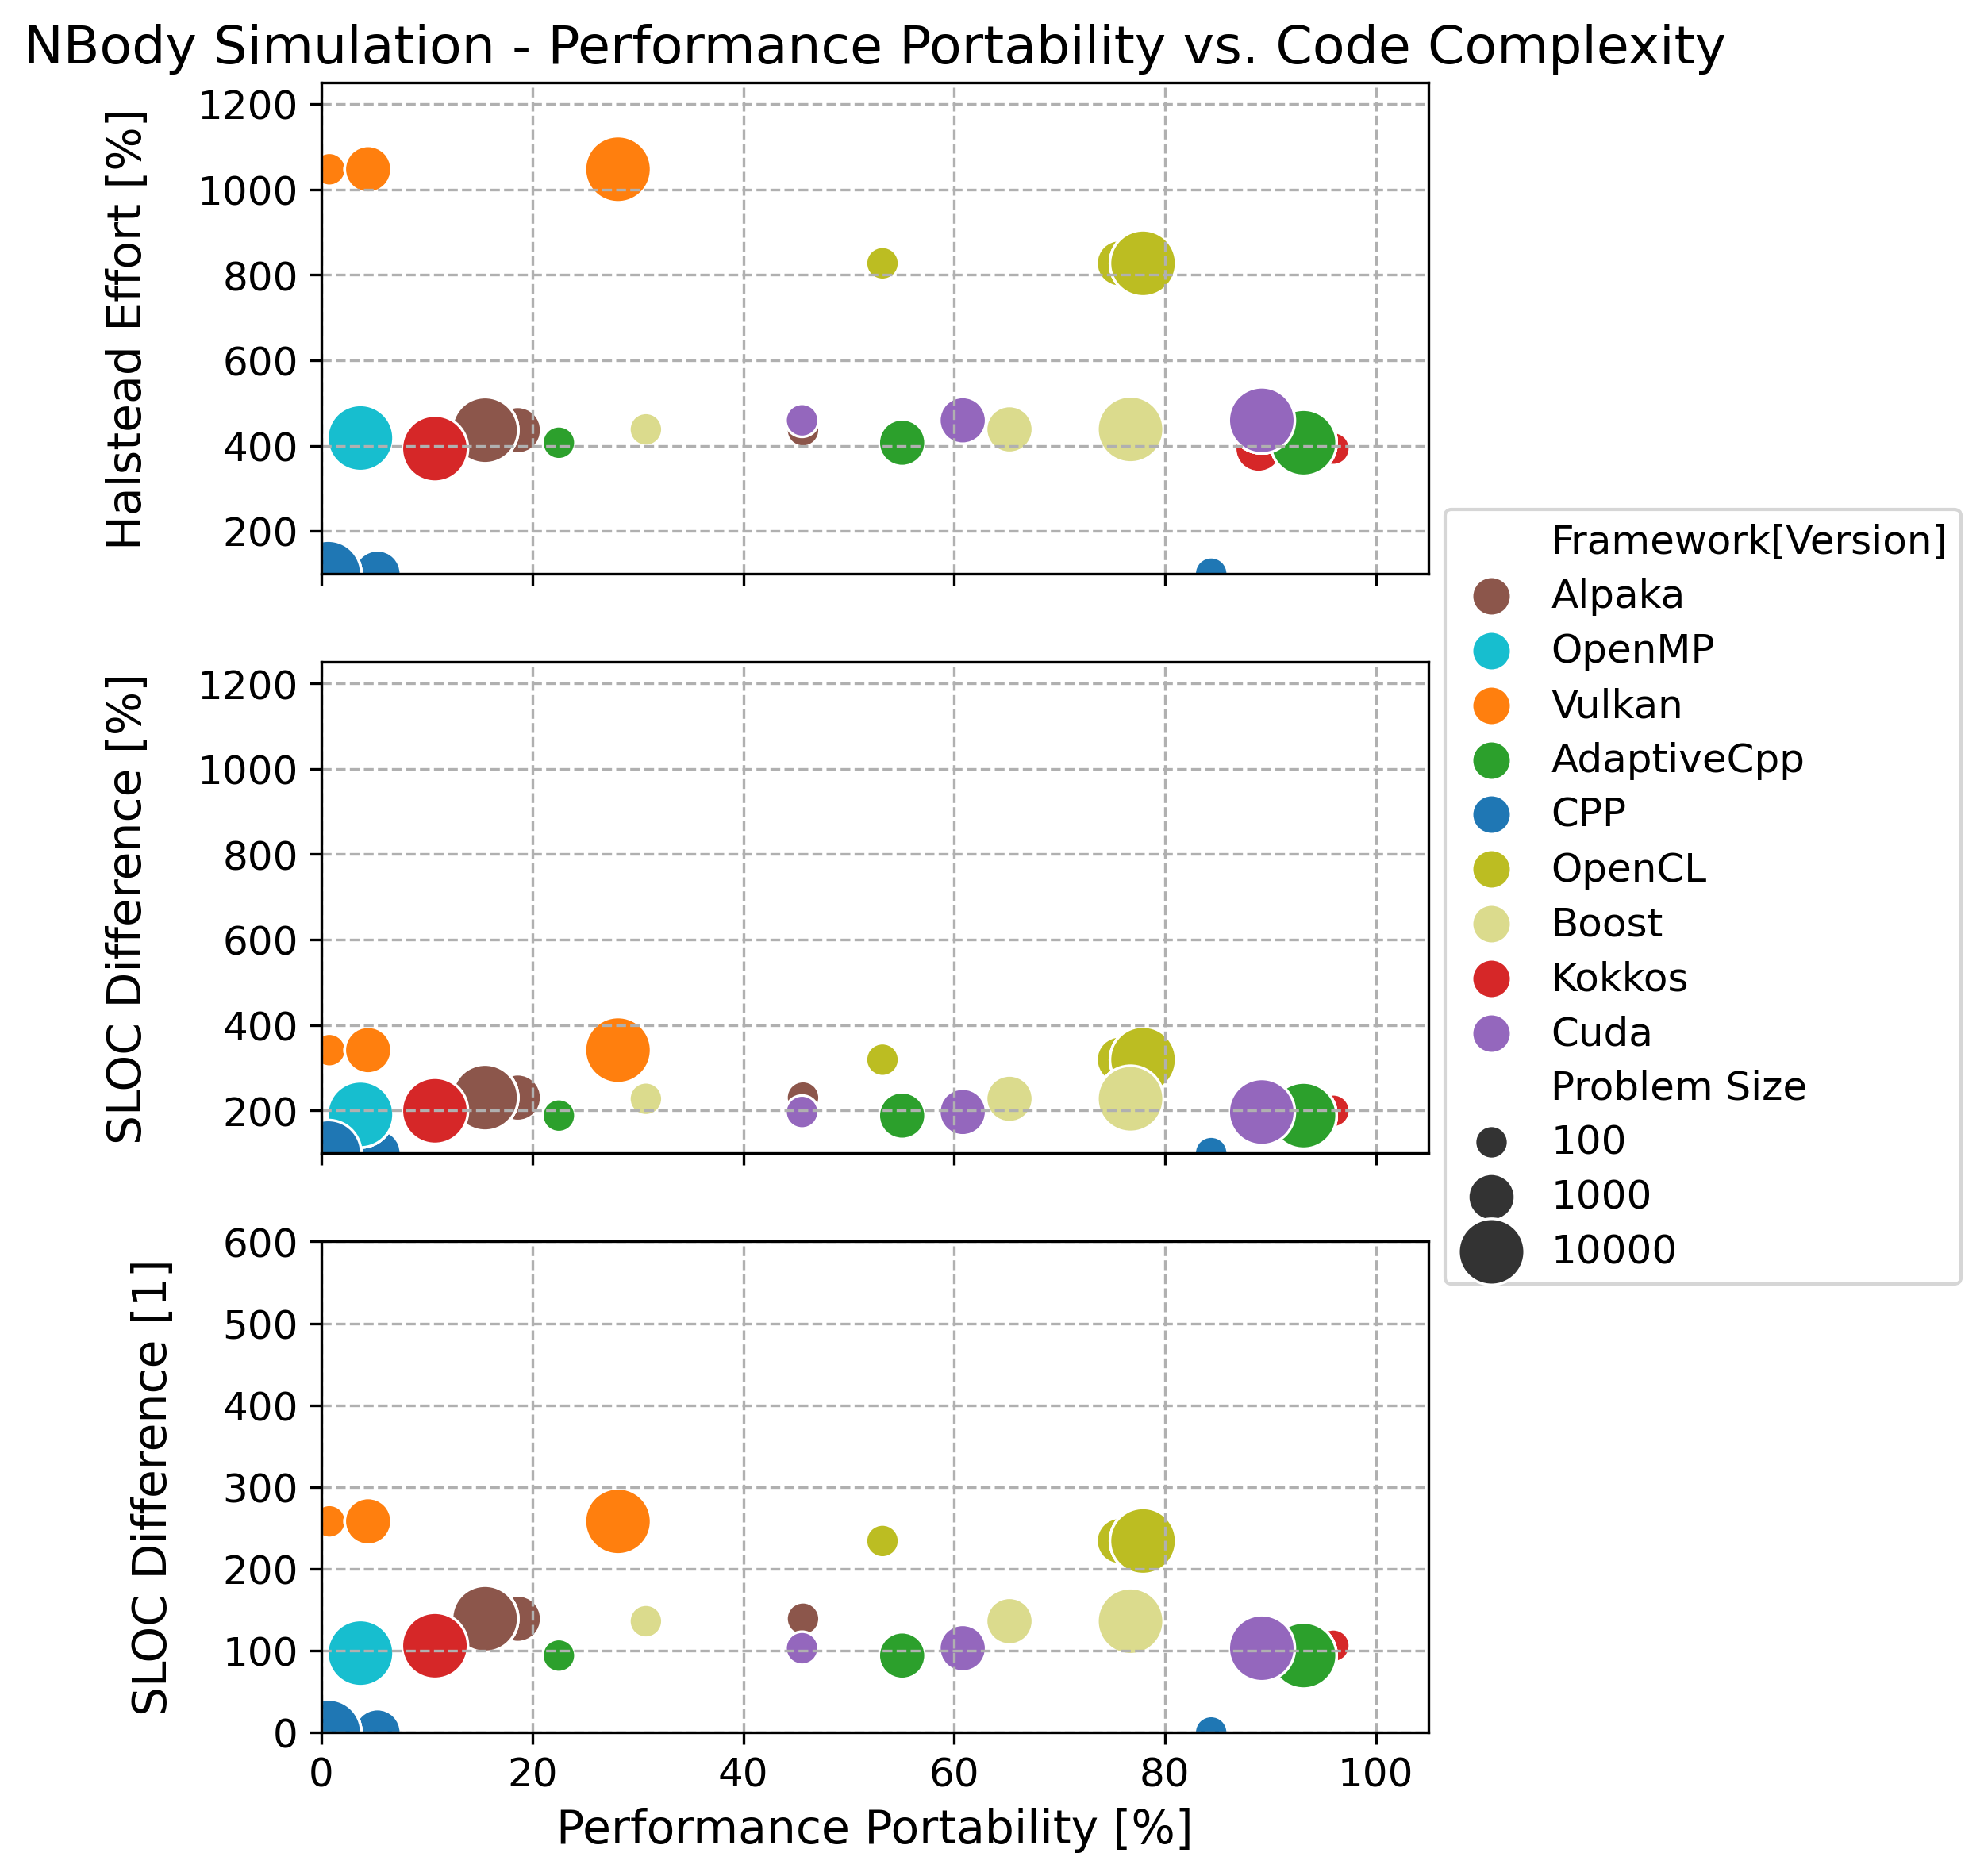

In [173]:
local_df = df_nbody
topic = "NBody Simulation"
x_axis = "Performance Portability [%]"
y1_axis = "Halstead Effort [%]"
y1_axis_lim = (100, 1250)
y2_axis = "SLOC Difference [%]"
y2_axis_lim = (100, 1250)
y3_axis = "SLOC Difference [1]"
y3_axis_lim = (0, 600)
sizes = [100, 200, 400]

fig, (ax_top, ax_mid, ax_bot) = plt.subplots(
    3, 1,
    sharex=True,
    figsize=(6, 9),
    gridspec_kw={"height_ratios": [1, 1, 1], "hspace": 0.18}
)

ax_top = sns.scatterplot(
    data=local_df,
    x=x_axis,
    y=y1_axis,
    hue=USE_FRAMEWORK,
    size="Problem Size",
    sizes=sizes,
    palette=color_map,
    s=140,
    ax=ax_top
)
ax_top.grid(True, linestyle="--")
ax_top.set_ylim(y1_axis_lim[0], y1_axis_lim[1])
ax_top.set_xlim(0, 105)
ax_top.set_title(f"{topic} - Performance Portability vs. Code Complexity", fontsize=16)
ax_top.set_xlabel("")
ax_top.set_ylabel(y1_axis, fontsize=14, labelpad=14)
ax_top.tick_params(axis="both", labelsize=12)
ax_top.tick_params(axis="x", labelbottom=False)

ax_mid = sns.scatterplot(
    data=local_df,
    x=x_axis,
    y=y2_axis,
    hue=USE_FRAMEWORK,
    size="Problem Size",
    sizes=sizes,
    palette=color_map,
    s=140,
    legend=False,
    ax=ax_mid
)
ax_mid.grid(True, linestyle="--")
ax_mid.set_ylim(y2_axis_lim[0], y2_axis_lim[1])
ax_mid.set_xlim(0, 105)
ax_mid.set_xlabel("")
ax_mid.set_ylabel(y2_axis, fontsize=14, labelpad=14)
ax_mid.tick_params(axis="both", labelsize=12)
ax_mid.tick_params(axis="x", labelbottom=False)

ax_bot = sns.scatterplot(
    data=local_df,
    x=x_axis,
    y=y3_axis,
    hue=USE_FRAMEWORK,
    size="Problem Size",
    sizes=sizes,
    palette=color_map,
    s=140,
    legend=False,
    ax=ax_bot
)
ax_bot.grid(True, linestyle="--")
ax_bot.set_ylim(y3_axis_lim[0], y3_axis_lim[1])
ax_bot.set_xlim(0, 105)
ax_bot.set_xlabel(x_axis, fontsize=14)
ax_bot.set_ylabel(y3_axis, fontsize=14, labelpad=14)
ax_bot.tick_params(axis="both", labelsize=12)

# Move shared legend to the right outside the plot
legend = ax_top.legend_
if legend is not None:
    handles, labels = legend.legend_handles, [t.get_text() for t in legend.texts]
    legend.remove()
    leg = fig.legend(
        handles, labels,
        loc="center left",
        bbox_to_anchor=(0.9, 0.5),
        frameon=True
    )
    if leg is not None:
        for txt in leg.get_texts():
            txt.set_fontsize(12)
        if leg.get_title() is not None:
            leg.get_title().set_fontsize(13)

fig.tight_layout(rect=(0.0, 0.0, 0.86, 1.0))
plt.gcf().set_dpi(300)
plt.show()


In [174]:
df_mm = filter_and_concat(df, [
    ("MatrixMultiplication", 1024, "Wall Clock Time"),
    ("MatrixMultiplication", 2048, "Wall Clock Time"),
    ("MatrixMultiplication", 4096, "Wall Clock Time"),
    ("MatrixMultiplication", 8192, "Wall Clock Time")
])

df_mm.loc[df_mm["Framework[Version]"] == "Cuda[SharedMemory]"]


,Framework,Wall Clock Time,CPU Time,Kernel Time,Position Update Time,Velocity Update Time,Force Update Time,Version,Framework[Version],GPU,...,D,E,Application Efficiency [%],Performance Portability [%],Halstead Effort [%],SLOC Difference [1],SLOC Difference [%],Name,Problem Size,Runtime Column
10,Cuda,3.272245e+06,3.271635e+06,1.488706e+06,NaN,NaN,NaN,SharedMemory,Cuda[SharedMemory],RTX2080,...,186.378641,2.070953e+06,100.000000,100.000000,1120.670687,84.0,275.0,MatrixMultiplication,1024,Wall Clock Time
45,Cuda,1.402251e+06,1.376093e+06,3.205203e+05,NaN,NaN,NaN,SharedMemory,Cuda[SharedMemory],RTX5080,...,186.378641,2.070953e+06,100.000000,100.000000,1120.670687,84.0,275.0,MatrixMultiplication,1024,Wall Clock Time
56,Cuda,2.126800e+07,2.126430e+07,1.130605e+07,NaN,NaN,NaN,SharedMemory,Cuda[SharedMemory],RTX2080,...,186.378641,2.070953e+06,97.807296,85.599371,1120.670687,84.0,275.0,MatrixMultiplication,2048,Wall Clock Time
91,Cuda,1.162014e+07,1.152241e+07,2.251931e+06,NaN,NaN,NaN,SharedMemory,Cuda[SharedMemory],RTX5080,...,186.378641,2.070953e+06,76.100770,85.599371,1120.670687,84.0,275.0,MatrixMultiplication,2048,Wall Clock Time
102,Cuda,1.278133e+08,1.278044e+08,8.864540e+07,NaN,NaN,NaN,SharedMemory,Cuda[SharedMemory],RTX2080,...,186.378641,2.070953e+06,100.000000,100.000000,1120.670687,84.0,275.0,MatrixMultiplication,4096,Wall Clock Time
137,Cuda,4.995488e+07,4.947784e+07,1.790708e+07,NaN,NaN,NaN,SharedMemory,Cuda[SharedMemory],RTX5080,...,186.378641,2.070953e+06,100.000000,100.000000,1120.670687,84.0,275.0,MatrixMultiplication,4096,Wall Clock Time
148,Cuda,9.007903e+08,9.007398e+08,7.387917e+08,NaN,NaN,NaN,SharedMemory,Cuda[SharedMemory],RTX2080,...,186.378641,2.070953e+06,100.000000,100.000000,1120.670687,84.0,275.0,MatrixMultiplication,8192,Wall Clock Time
183,Cuda,2.814010e+08,2.813402e+08,1.544852e+08,NaN,NaN,NaN,SharedMemory,Cuda[SharedMemory],RTX5080,...,186.378641,2.070953e+06,100.000000,100.000000,1120.670687,84.0,275.0,MatrixMultiplication,8192,Wall Clock Time


/var/folders/d7/j4pv5c3d1nj5jmjlz_bpj2lh0000gn/T/ipykernel_50564/2348279270.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0.0, 0.0, 0.86, 1.0))


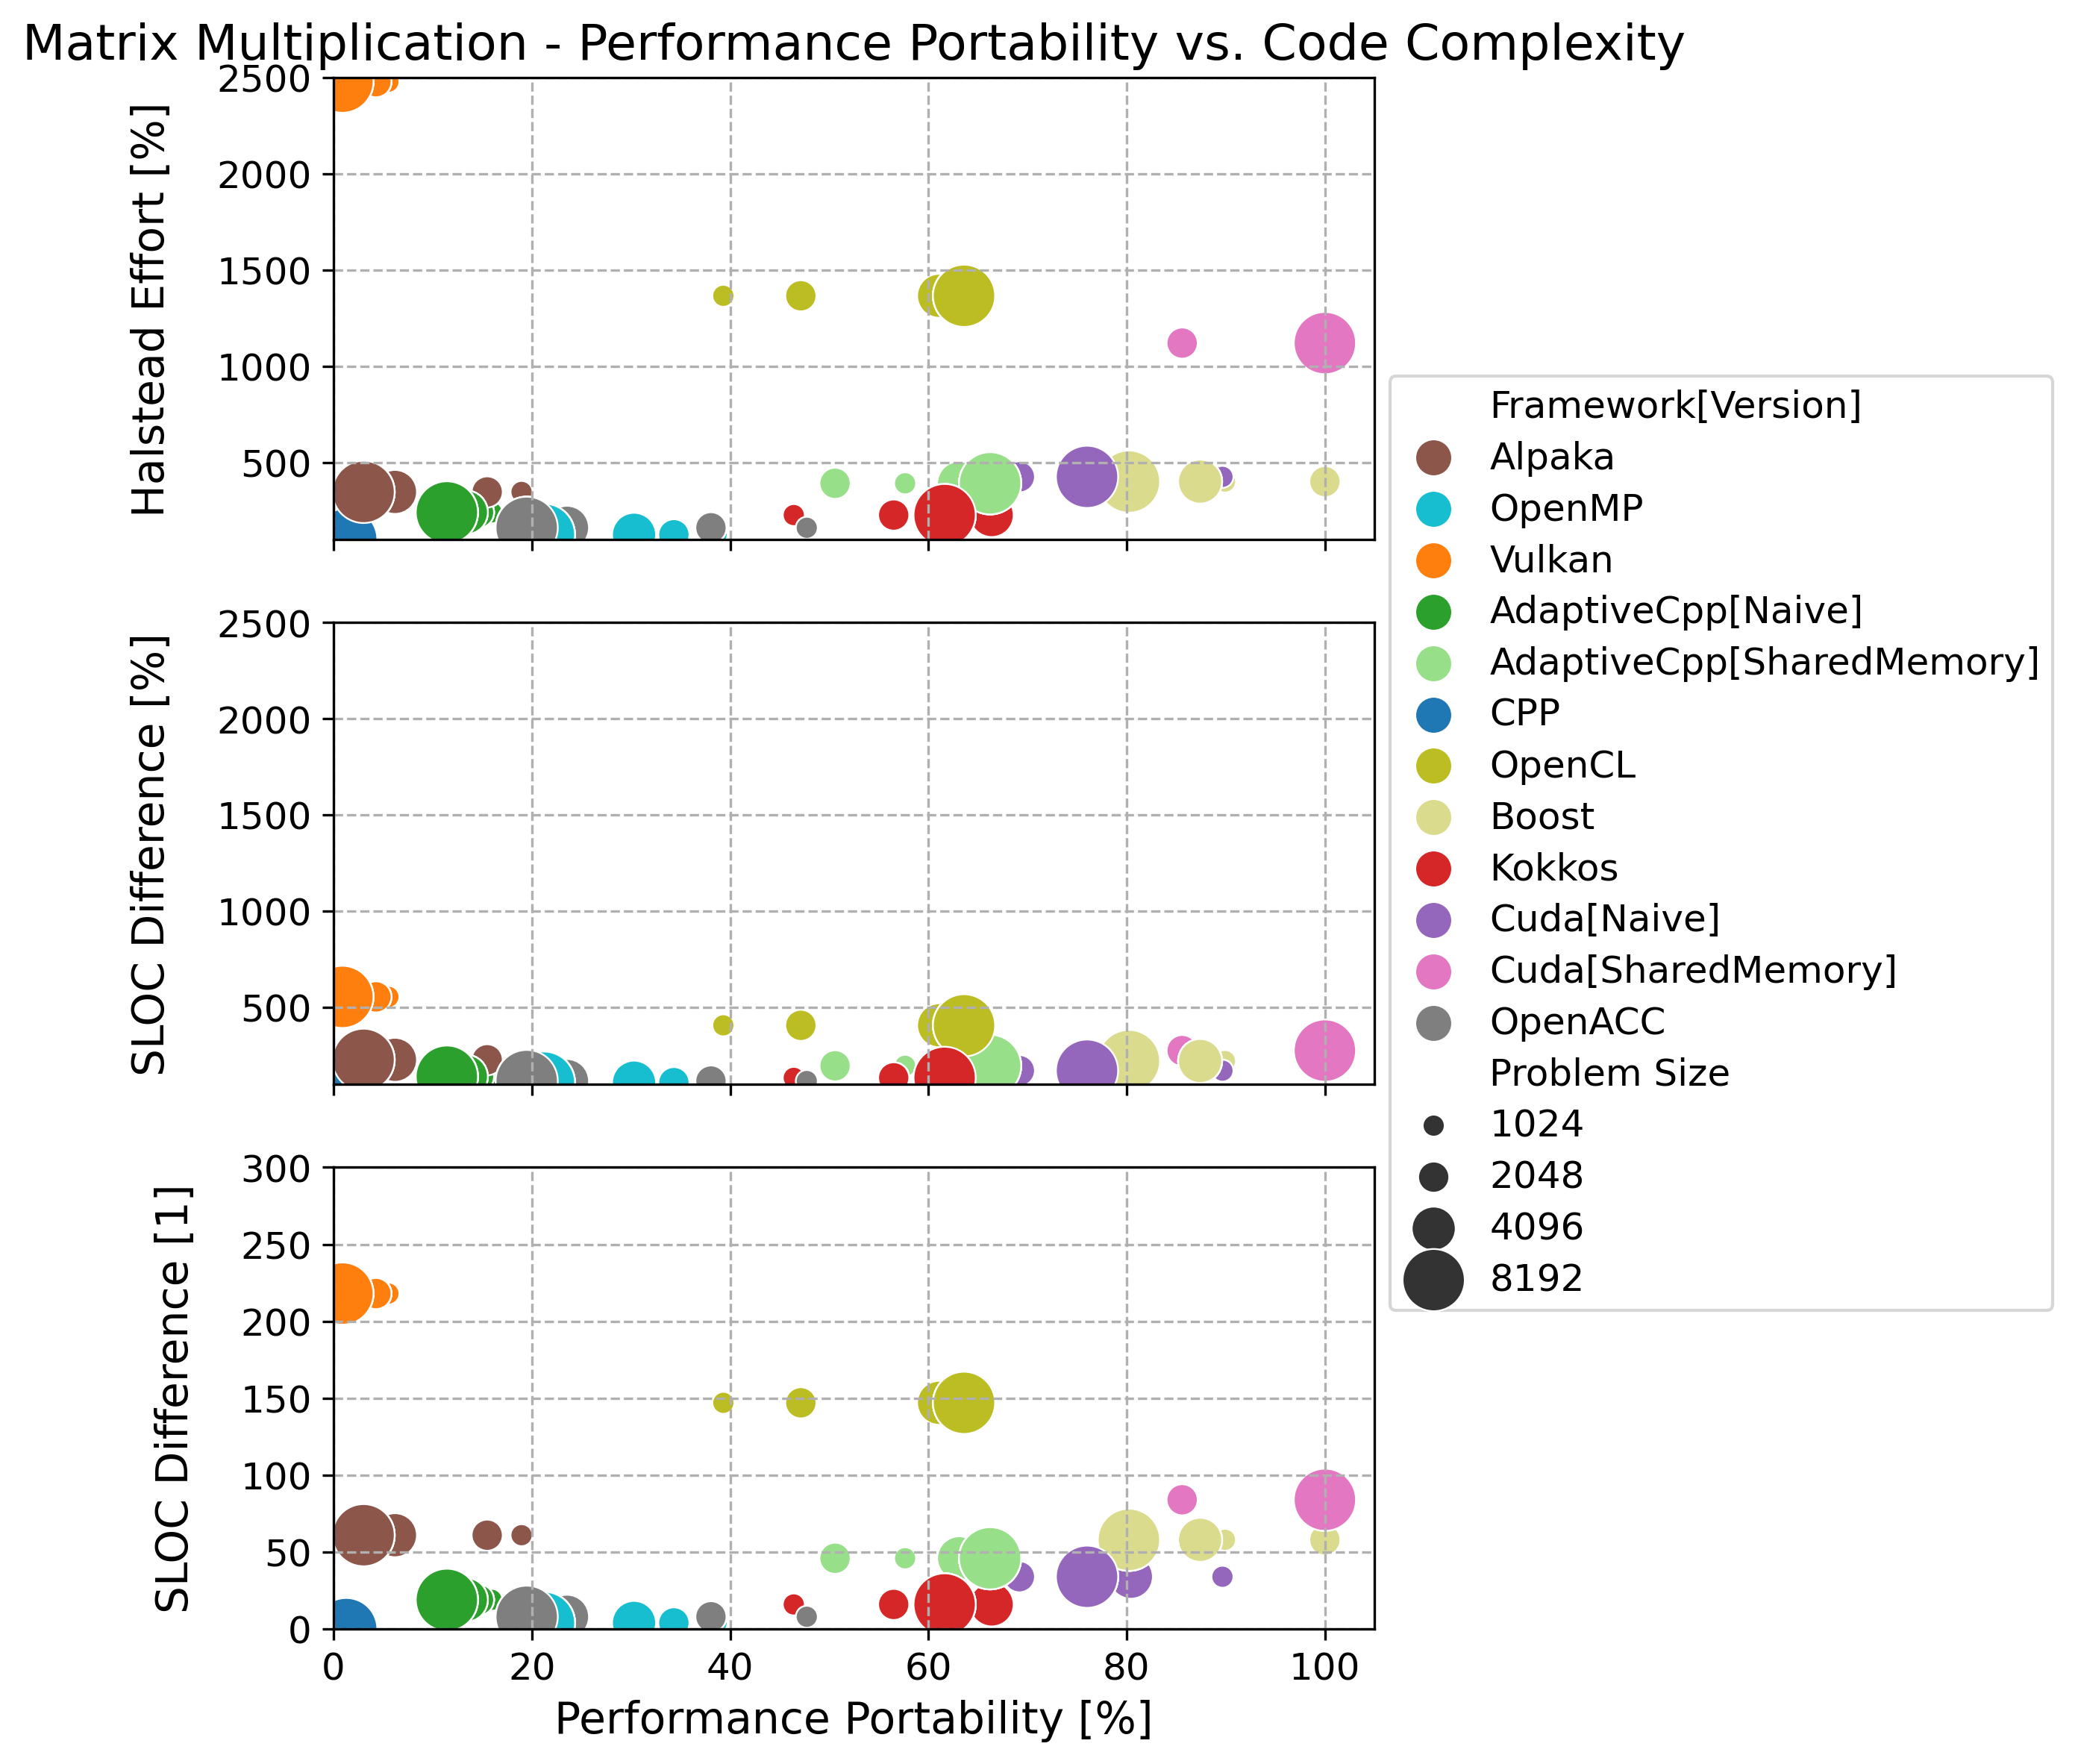

In [176]:
local_df = df_mm
topic = "Matrix Multiplication"
x_axis = "Performance Portability [%]"
y1_axis = "Halstead Effort [%]"
y1_axis_lim = (100, 2500)
y2_axis = "SLOC Difference [%]"
y2_axis_lim = (100, 2500)
y3_axis = "SLOC Difference [1]"
y3_axis_lim = (0, 300)
sizes = [50, 100, 200, 400]

fig, (ax_top, ax_mid, ax_bot) = plt.subplots(
    3, 1,
    sharex=True,
    figsize=(6, 9),
    gridspec_kw={"height_ratios": [1, 1, 1], "hspace": 0.18}
)

ax_top = sns.scatterplot(
    data=local_df,
    x=x_axis,
    y=y1_axis,
    hue=USE_FRAMEWORK,
    size="Problem Size",
    sizes=sizes,
    palette=color_map,
    s=140,
    ax=ax_top
)
ax_top.grid(True, linestyle="--")
ax_top.set_ylim(y1_axis_lim[0], y1_axis_lim[1])
ax_top.set_xlim(0, 105)
ax_top.set_title(f"{topic} - Performance Portability vs. Code Complexity", fontsize=16)
ax_top.set_xlabel("")
ax_top.set_ylabel(y1_axis, fontsize=14, labelpad=14)
ax_top.tick_params(axis="both", labelsize=12)
ax_top.tick_params(axis="x", labelbottom=False)

ax_mid = sns.scatterplot(
    data=local_df,
    x=x_axis,
    y=y2_axis,
    hue=USE_FRAMEWORK,
    size="Problem Size",
    sizes=sizes,
    palette=color_map,
    s=140,
    legend=False,
    ax=ax_mid
)
ax_mid.grid(True, linestyle="--")
ax_mid.set_ylim(y2_axis_lim[0], y2_axis_lim[1])
ax_mid.set_xlim(0, 105)
ax_mid.set_xlabel("")
ax_mid.set_ylabel(y2_axis, fontsize=14, labelpad=14)
ax_mid.tick_params(axis="both", labelsize=12)
ax_mid.tick_params(axis="x", labelbottom=False)

ax_bot = sns.scatterplot(
    data=local_df,
    x=x_axis,
    y=y3_axis,
    hue=USE_FRAMEWORK,
    size="Problem Size",
    sizes=sizes,
    palette=color_map,
    s=140,
    legend=False,
    ax=ax_bot
)
ax_bot.grid(True, linestyle="--")
ax_bot.set_ylim(y3_axis_lim[0], y3_axis_lim[1])
ax_bot.set_xlim(0, 105)
ax_bot.set_xlabel(x_axis, fontsize=14)
ax_bot.set_ylabel(y3_axis, fontsize=14, labelpad=14)
ax_bot.tick_params(axis="both", labelsize=12)

# Move shared legend to the right outside the plot
legend = ax_top.legend_
if legend is not None:
    handles, labels = legend.legend_handles, [t.get_text() for t in legend.texts]
    legend.remove()
    leg = fig.legend(
        handles, labels,
        loc="center left",
        bbox_to_anchor=(0.9, 0.5),
        frameon=True
    )
    if leg is not None:
        for txt in leg.get_texts():
            txt.set_fontsize(12)
        if leg.get_title() is not None:
            leg.get_title().set_fontsize(13)

fig.tight_layout(rect=(0.0, 0.0, 0.86, 1.0))
plt.gcf().set_dpi(300)
plt.show()


In [180]:
df_vec = filter_and_concat(df, [
    ("VecAdd", 1000000, "Wall Clock Time"),
    ("VecAdd", 10000000, "Wall Clock Time"),
    ("VecAdd", 100000000, "Wall Clock Time")
])
df_vec

,Framework,Wall Clock Time,CPU Time,Kernel Time,Position Update Time,Velocity Update Time,Force Update Time,Version,Framework[Version],GPU,...,D,E,Application Efficiency [%],Performance Portability [%],Halstead Effort [%],SLOC Difference [1],SLOC Difference [%],Name,Problem Size,Runtime Column
0,Alpaka,1.559989e+06,1.559425e+06,3.219186e+04,NaN,NaN,NaN,NaN,Alpaka,RTX2080,...,67.604167,3.768999e+05,100.000000,99.042602,560.716872,53.0,276.666667,VecAdd,1000000,Wall Clock Time
1,OpenMP,6.286328e+06,2.506753e+06,4.589668e+06,NaN,NaN,NaN,NaN,OpenMP,RTX2080,...,51.367925,1.155265e+05,24.815580,23.422558,171.869687,7.0,123.333333,VecAdd,1000000,Wall Clock Time
2,Vulkan,1.365059e+07,1.143164e+07,4.553823e+05,NaN,NaN,NaN,NaN,Vulkan,RTX2080,...,178.656566,3.160996e+06,11.427993,6.620878,4702.637790,176.0,686.666667,VecAdd,1000000,Wall Clock Time
3,AdaptiveCpp,3.954775e+06,3.337764e+06,3.377589e+05,NaN,NaN,NaN,NaN,AdaptiveCpp,RTX2080,...,62.562500,2.110938e+05,39.445704,30.350619,314.045827,17.0,156.666667,VecAdd,1000000,Wall Clock Time
4,CPP,1.666572e+06,1.666448e+06,1.628865e+05,NaN,NaN,NaN,NaN,CPP,RTX2080,...,39.202381,6.721751e+04,93.604643,60.499010,100.000000,0.0,100.000000,VecAdd,1000000,Wall Clock Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,Vulkan,2.172911e+09,2.070499e+09,2.170686e+06,NaN,NaN,NaN,NaN,Vulkan,RTX5080,...,178.656566,3.160996e+06,8.407640,9.441646,4702.637790,176.0,686.666667,VecAdd,100000000,Wall Clock Time
107,Alpaka,1.826905e+08,1.816426e+08,1.404925e+06,NaN,NaN,NaN,NaN,Alpaka,RTX5080,...,67.604167,3.768999e+05,100.000000,100.000000,560.716872,53.0,276.666667,VecAdd,100000000,Wall Clock Time
108,Kokkos,5.113408e+08,5.113238e+08,2.056741e+06,NaN,NaN,NaN,NaN,Kokkos,RTX5080,...,63.688679,1.912407e+05,35.727736,34.640365,284.510267,15.0,150.000000,VecAdd,100000000,Wall Clock Time
109,OpenACC,2.769015e+08,2.768566e+08,7.764126e+07,NaN,NaN,NaN,NaN,OpenACC,RTX5080,...,61.500000,1.520564e+05,65.976712,63.837027,226.215489,11.0,136.666667,VecAdd,100000000,Wall Clock Time


/var/folders/d7/j4pv5c3d1nj5jmjlz_bpj2lh0000gn/T/ipykernel_50564/3372878471.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0.0, 0.0, 0.86, 1.0))


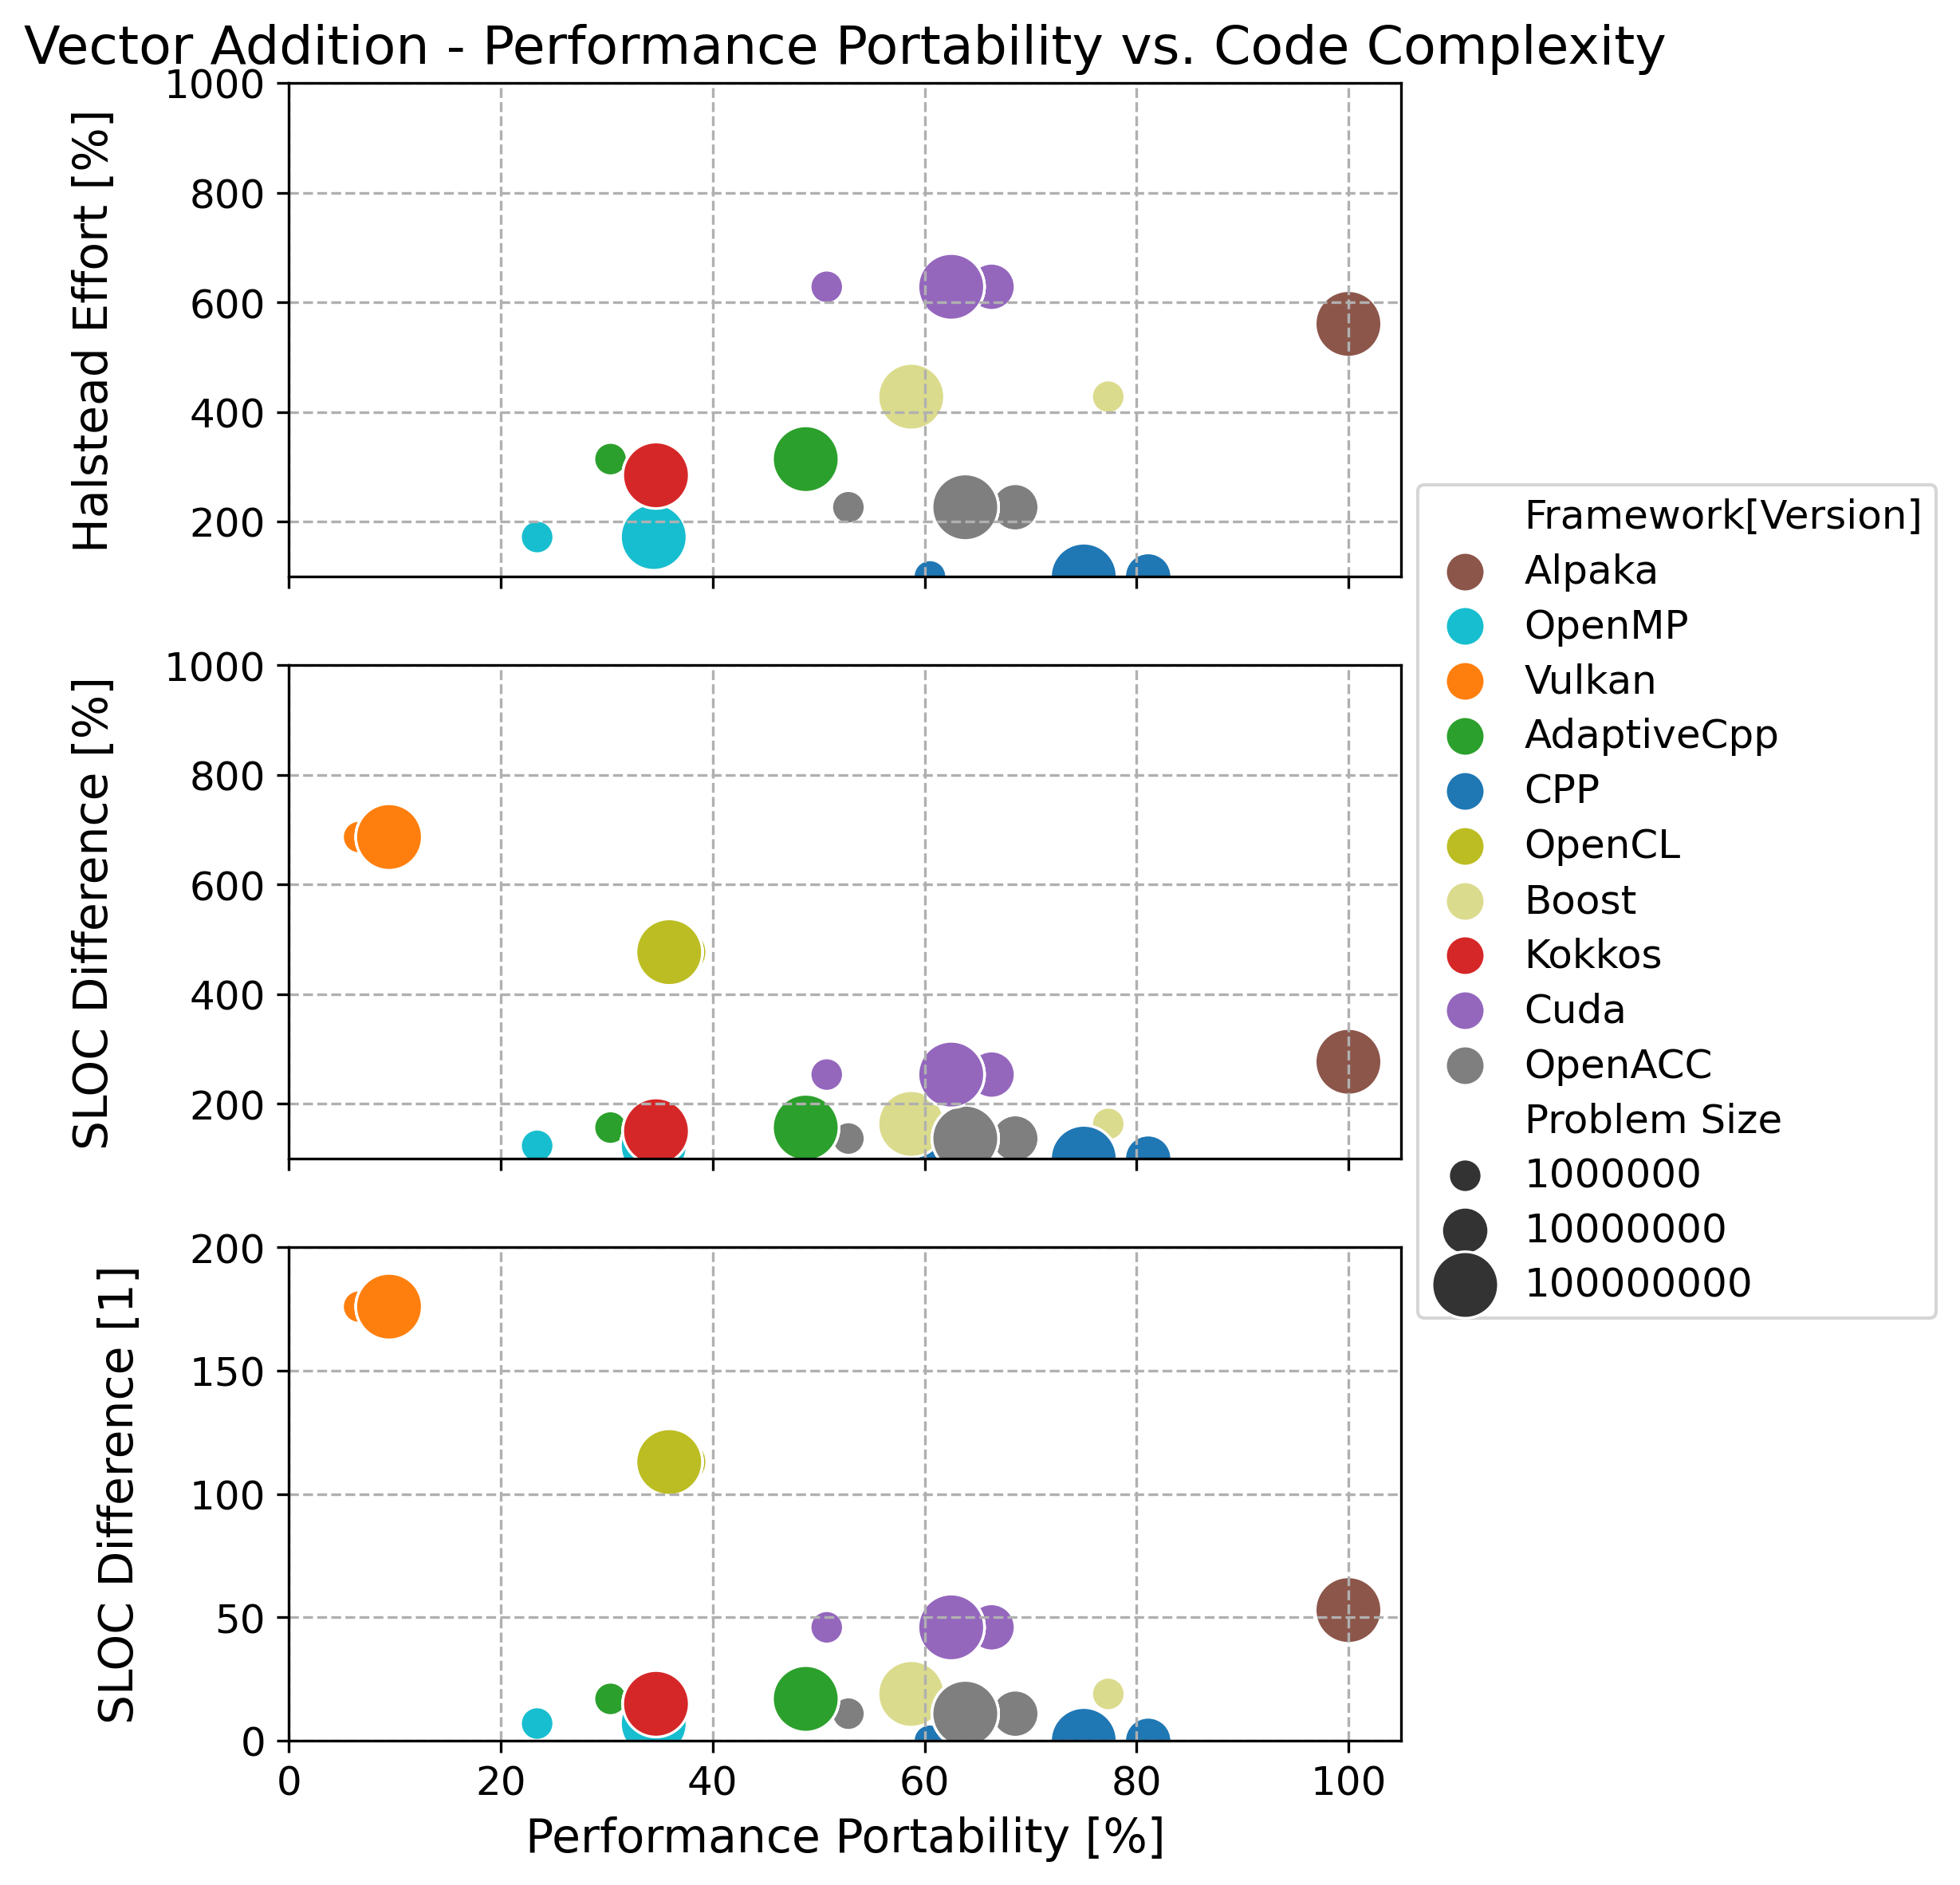

In [182]:
local_df = df_vec
topic = "Vector Addition"
x_axis = "Performance Portability [%]"
y1_axis = "Halstead Effort [%]"
y1_axis_lim = (100, 1000)
y2_axis = "SLOC Difference [%]"
y2_axis_lim = (100, 1000)
y3_axis = "SLOC Difference [1]"
y3_axis_lim = (0, 200)
sizes = [100, 200, 400]

fig, (ax_top, ax_mid, ax_bot) = plt.subplots(
    3, 1,
    sharex=True,
    figsize=(6, 9),
    gridspec_kw={"height_ratios": [1, 1, 1], "hspace": 0.18}
)

ax_top = sns.scatterplot(
    data=local_df,
    x=x_axis,
    y=y1_axis,
    hue=USE_FRAMEWORK,
    size="Problem Size",
    sizes=sizes,
    palette=color_map,
    s=140,
    ax=ax_top
)
ax_top.grid(True, linestyle="--")
ax_top.set_ylim(y1_axis_lim[0], y1_axis_lim[1])
ax_top.set_xlim(0, 105)
ax_top.set_title(f"{topic} - Performance Portability vs. Code Complexity", fontsize=16)
ax_top.set_xlabel("")
ax_top.set_ylabel(y1_axis, fontsize=14, labelpad=14)
ax_top.tick_params(axis="both", labelsize=12)
ax_top.tick_params(axis="x", labelbottom=False)

ax_mid = sns.scatterplot(
    data=local_df,
    x=x_axis,
    y=y2_axis,
    hue=USE_FRAMEWORK,
    size="Problem Size",
    sizes=sizes,
    palette=color_map,
    s=140,
    legend=False,
    ax=ax_mid
)
ax_mid.grid(True, linestyle="--")
ax_mid.set_ylim(y2_axis_lim[0], y2_axis_lim[1])
ax_mid.set_xlim(0, 105)
ax_mid.set_xlabel("")
ax_mid.set_ylabel(y2_axis, fontsize=14, labelpad=14)
ax_mid.tick_params(axis="both", labelsize=12)
ax_mid.tick_params(axis="x", labelbottom=False)

ax_bot = sns.scatterplot(
    data=local_df,
    x=x_axis,
    y=y3_axis,
    hue=USE_FRAMEWORK,
    size="Problem Size",
    sizes=sizes,
    palette=color_map,
    s=140,
    legend=False,
    ax=ax_bot
)
ax_bot.grid(True, linestyle="--")
ax_bot.set_ylim(y3_axis_lim[0], y3_axis_lim[1])
ax_bot.set_xlim(0, 105)
ax_bot.set_xlabel(x_axis, fontsize=14)
ax_bot.set_ylabel(y3_axis, fontsize=14, labelpad=14)
ax_bot.tick_params(axis="both", labelsize=12)

# Move shared legend to the right outside the plot
legend = ax_top.legend_
if legend is not None:
    handles, labels = legend.legend_handles, [t.get_text() for t in legend.texts]
    legend.remove()
    leg = fig.legend(
        handles, labels,
        loc="center left",
        bbox_to_anchor=(0.9, 0.5),
        frameon=True
    )
    if leg is not None:
        for txt in leg.get_texts():
            txt.set_fontsize(12)
        if leg.get_title() is not None:
            leg.get_title().set_fontsize(13)

fig.tight_layout(rect=(0.0, 0.0, 0.86, 1.0))
plt.gcf().set_dpi(300)
plt.show()
